# Experiment 1: Multi-Regime PPO for Market Making

## Generalization and Robustness Comparison on Unseen Markets

This notebook implements Experiment 1 from the paper, comparing:
- Fixed Spread (baseline)
- Avellaneda-Stoikov (mathematical finance baseline)
- Single-Regime PPO (trained only on R2)
- Multi-Regime PPO (trained on R1-R6 with episode-level regime randomization)

Test environments: U1 (interpolated unseen market) and U2 (extrapolated stress market)

Metrics: Mean PnL, CVaR(10%), Var(q_T)

## 1. Imports and Setup

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecMonitor

from mbt_gym.agents.BaselineAgents import FixedSpreadAgent, AvellanedaStoikovAgent
from mbt_gym.agents.SbAgent import SbAgent
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.wrappers import ReduceStateSizeWrapper
from mbt_gym.gym.index_names import INVENTORY_INDEX, TIME_INDEX, CASH_INDEX, ASSET_PRICE_INDEX
from mbt_gym.rewards.RewardFunctions import PnL, CjMmCriterion
from mbt_gym.stochastic_processes.midprice_models import BrownianMotionMidpriceModel
from mbt_gym.stochastic_processes.arrival_models import PoissonArrivalModel
from mbt_gym.stochastic_processes.fill_probability_models import ExponentialFillFunction
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics

2026-03-30 05:32:26.935725: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-30 05:32:27.258629: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-30 05:32:27.258771: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-30 05:32:27.312682: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-30 05:32:27.423200: I tensorflow/core/platform/cpu_feature_guar

## 2. Define Market Regimes

### Imports and Global Setup
Load dependencies, set paths and constants, and ensure the notebook runs within the current project structure.

In [ ]:
REGIME_PARAMS = {
    'R1': {'sigma': 0.5, 'A': 1.0, 'k': 1.0},
    'R2': {'sigma': 1.0, 'A': 1.0, 'k': 1.0},
    'R3': {'sigma': 1.5, 'A': 1.0, 'k': 1.0},
    'R4': {'sigma': 1.0, 'A': 1.5, 'k': 1.0},
    'R5': {'sigma': 1.0, 'A': 0.5, 'k': 1.0},
    'R6': {'sigma': 1.5, 'A': 0.5, 'k': 1.5},
    'U1': {'sigma': 1.25, 'A': 1.0, 'k': 1.0},
    'U2': {'sigma': 2.0, 'A': 0.5, 'k': 1.5},
}

SEEN_REGIMES = ['R1', 'R2', 'R3', 'R4', 'R5', 'R6']
UNSEEN_REGIMES = ['U1', 'U2']

TERMINAL_TIME = 1.0
INITIAL_INVENTORY = 0
INITIAL_PRICE = 100
STEP_SIZE_FACTOR = 10

# ===== Fair Comparison Settings =====
# REWARD_MODE='pnl'   -> Optimize only for PnL (reward)
# REWARD_MODE='cjmm'  -> PnL + inventory penalty (emphasize risk control)
REWARD_MODE = 'cjmm'
CJMM_PHI = 0.01
CJMM_ALPHA = 0.001

# AS risk aversion parameter (gamma in the Avellaneda-Stoikov analytical formula)
AS_RISK_AVERSION = 0.1

## 3. Environment Factory Function

### Regime Parameters: R1-R6 (seen) and U1-U2 (unseen)
Define the \(\sigma, A, k\) parameters for each market regime, and the regime lists used for training and evaluation.

In [3]:
def create_market_env(
    regime_name: str,
    num_trajectories: int = 1,
    seed: int = None,
    reward_mode: str = REWARD_MODE,
    phi: float = CJMM_PHI,
    alpha: float = CJMM_ALPHA,
):
    params = REGIME_PARAMS[regime_name]
    sigma = params['sigma']
    A = params['A']
    k = params['k']
    
    arrival_rate = 10.0 * A
    n_steps = int(STEP_SIZE_FACTOR * TERMINAL_TIME * arrival_rate)
    step_size = TERMINAL_TIME / n_steps
    
    midprice_model = BrownianMotionMidpriceModel(
        volatility=sigma,
        terminal_time=TERMINAL_TIME,
        step_size=step_size,
        initial_price=INITIAL_PRICE,
        num_trajectories=num_trajectories,
        seed=seed
    )
    
    arrival_model = PoissonArrivalModel(
        intensity=np.array([arrival_rate, arrival_rate]),
        step_size=step_size,
        num_trajectories=num_trajectories,
        seed=seed
    )
    
    fill_probability_model = ExponentialFillFunction(
        fill_exponent=k,
        step_size=step_size,
        num_trajectories=num_trajectories,
        seed=seed
    )
    
    model_dynamics = LimitOrderModelDynamics(
        midprice_model=midprice_model,
        arrival_model=arrival_model,
        fill_probability_model=fill_probability_model,
        num_trajectories=num_trajectories,
        seed=seed
    )
    
    if reward_mode == 'pnl':
        reward_function = PnL()
    elif reward_mode == 'cjmm':
        reward_function = CjMmCriterion(
            per_step_inventory_aversion=phi,
            terminal_inventory_aversion=alpha,
        )
    else:
        raise ValueError(f"Unknown reward_mode: {reward_mode}. Use 'pnl' or 'cjmm'.")
    
    env = TradingEnvironment(
        terminal_time=TERMINAL_TIME,
        n_steps=n_steps,
        model_dynamics=model_dynamics,
        reward_function=reward_function,
        initial_inventory=INITIAL_INVENTORY,
        max_inventory=n_steps,
        num_trajectories=num_trajectories,
        normalise_action_space=True,
        normalise_observation_space=True,
        seed=seed
    )
    
    return env

## 4. Evaluation Function

### Environment Construction: Create a Market Environment by Regime
Wrap `create_market_env()` to construct and return the trading environment (including normalization settings) based on the provided regime parameters.

In [4]:
class NormalizedASAgent:
    """Adapter: Ensure Avellaneda-Stoikov interacts correctly with the normalized environment."""

    def __init__(self, env, risk_aversion: float = AS_RISK_AVERSION):
        self.env = env
        self.base_agent = AvellanedaStoikovAgent(risk_aversion=risk_aversion, env=env)
        self.risk_aversion = risk_aversion

    def get_action(self, obs: np.ndarray) -> np.ndarray:
        # 1) Denormalize the observation first, then feed it to AS' analytical formula
        raw_obs = self.env.normalise_observation(obs, inverse=True)

        # 2) AS outputs physical-scale actions (depth / half-spread)
        raw_action = self.base_agent.get_action(raw_obs)

        # 3) Renormalize to the action range expected by env.step()
        norm_action = self.env.normalise_action(raw_action, inverse=False)

        # Stability guard: clip to [-1, 1] to avoid out-of-range distortion
        return np.clip(norm_action, -1.0, 1.0)


def evaluate_agent(agent, env, n_episodes: int = 1000, seed: int = 42):
    np.random.seed(seed)

    pnl_list = []
    terminal_inventory_list = []

    for episode in range(n_episodes):
        obs = env.reset()
        done = False

        # Evaluation definition: PnL = terminal portfolio value - initial portfolio value
        initial_state = np.asarray(env.state)
        initial_market_value = float(
            initial_state[0, CASH_INDEX] + initial_state[0, INVENTORY_INDEX] * initial_state[0, ASSET_PRICE_INDEX]
        )

        terminal_inventory = 0.0

        while not done:
            action = agent.get_action(obs)
            obs, reward, done, _ = env.step(action)

            # obs is the normalized observation; inventory statistics should be based on the environment's original state
            terminal_inventory = float(np.asarray(env.state)[0, INVENTORY_INDEX])

        terminal_state = np.asarray(env.state)
        terminal_market_value = float(
            terminal_state[0, CASH_INDEX] + terminal_state[0, INVENTORY_INDEX] * terminal_state[0, ASSET_PRICE_INDEX]
        )
        episode_pnl = terminal_market_value - initial_market_value

        pnl_list.append(float(episode_pnl))
        terminal_inventory_list.append(float(terminal_inventory))

    # Force 1D to ensure sorting and CVaR are computed along the episode dimension
    pnl_array = np.asarray(pnl_list, dtype=np.float64).reshape(-1)
    inv_array = np.asarray(terminal_inventory_list, dtype=np.float64).reshape(-1)

    sorted_pnls = np.sort(pnl_array)
    n_worst_10 = max(1, int(0.1 * len(sorted_pnls)))
    n_worst_30 = max(1, int(0.3 * len(sorted_pnls)))
    cvar_10 = float(np.mean(sorted_pnls[:n_worst_10]))
    cvar_30 = float(np.mean(sorted_pnls[:n_worst_30]))

    return {
        'mean_pnl': float(np.mean(pnl_array)),
        'cvar_10': cvar_10,
        'cvar_30': cvar_30,
        'mean_qt': float(np.mean(inv_array)),
        'var_inventory': float(np.var(inv_array)),
        'all_pnls': pnl_array,
        'all_terminal_inventories': inv_array
    }

## 5. Train PPO Models (Optional - set flags to False to skip training)

### Evaluation Function: Metric Computation and Adapters
Define the evaluation function (Mean PnL, CVaR, inventory statistics, etc.) and the agent adapters required to interact with the normalized environment.

In [ ]:
from pathlib import Path

MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SINGLE_MODEL_PATH = MODEL_DIR / "single_ppo_r2.zip"
SINGLE_MODEL_PATH_R4 = MODEL_DIR / "single_ppo_r4.zip"
MULTI_MODEL_PATH = MODEL_DIR / "multi_ppo_r1_r6.zip"

TRAIN_SINGLE_PPO = False
TRAIN_SINGLE_R4_PPO = False
TRAIN_MULTI_PPO = False

# If model files do not exist, automatically switch to training mode to avoid errors when running end-to-end
if not SINGLE_MODEL_PATH.exists():
    TRAIN_SINGLE_PPO = True
if not SINGLE_MODEL_PATH_R4.exists():
    TRAIN_SINGLE_R4_PPO = True
if not MULTI_MODEL_PATH.exists():
    TRAIN_MULTI_PPO = True

# Use a smaller default number of training steps
TRAINING_TIMESTEPS = 200_000
seed = 42

single_ppo_model = None
single_r4_ppo_model = None
multi_ppo_model = None

if TRAIN_SINGLE_PPO:
    print("Training Single-Regime PPO on R2...")
    num_trajectories = 100
    env = create_market_env('R2', num_trajectories=num_trajectories, seed=seed)
    wrapped_env = StableBaselinesTradingEnvironment(ReduceStateSizeWrapper(env))
    wrapped_env = VecMonitor(wrapped_env)
    
    policy_kwargs = dict(net_arch=[dict(pi=[128, 128], vf=[128, 128])])
    
    model = PPO(
        'MlpPolicy',
        wrapped_env,
        verbose=0,
        policy_kwargs=policy_kwargs,
        n_epochs=10,
        batch_size=int(env.n_steps * num_trajectories / 4),
        n_steps=int(env.n_steps),
        gamma=1.0,
        seed=seed
    )
    
    model.learn(total_timesteps=TRAINING_TIMESTEPS, progress_bar=True)
    single_ppo_model = model
    model.save(str(SINGLE_MODEL_PATH))
    print("Single-Regime PPO saved.")
else:
    try:
        single_ppo_model = PPO.load(str(SINGLE_MODEL_PATH))
        print("Loaded existing Single-Regime PPO model.")
    except Exception as e:
        print(f"Failed to load Single-PPO ({e}). Set TRAIN_SINGLE_PPO=True to train.")

if TRAIN_SINGLE_R4_PPO:
    print("Training Single-Regime PPO on R4...")
    num_trajectories = 100
    env = create_market_env('R4', num_trajectories=num_trajectories, seed=seed)
    wrapped_env = StableBaselinesTradingEnvironment(ReduceStateSizeWrapper(env))
    wrapped_env = VecMonitor(wrapped_env)

    policy_kwargs = dict(net_arch=[dict(pi=[128, 128], vf=[128, 128])])

    model = PPO(
        'MlpPolicy',
        wrapped_env,
        verbose=0,
        policy_kwargs=policy_kwargs,
        n_epochs=10,
        batch_size=int(env.n_steps * num_trajectories / 4),
        n_steps=int(env.n_steps),
        gamma=1.0,
        seed=seed
    )

    model.learn(total_timesteps=TRAINING_TIMESTEPS, progress_bar=True)
    single_r4_ppo_model = model
    model.save(str(SINGLE_MODEL_PATH_R4))
    print("Single-Regime PPO (R4) saved.")
else:
    try:
        single_r4_ppo_model = PPO.load(str(SINGLE_MODEL_PATH_R4))
        print("Loaded existing Single-Regime PPO (R4) model.")
    except Exception as e:
        print(f"Failed to load Single-R4-PPO ({e}). Set TRAIN_SINGLE_R4_PPO=True to train.")

if TRAIN_MULTI_PPO:
    print("Training Multi-Regime PPO on R1-R6 (episode-level regime sampling)...")
    num_trajectories = 100

    # Initialize the model using an arbitrary seen regime
    env = create_market_env('R1', num_trajectories=num_trajectories, seed=seed)
    wrapped_env = StableBaselinesTradingEnvironment(ReduceStateSizeWrapper(env))
    wrapped_env = VecMonitor(wrapped_env)

    policy_kwargs = dict(net_arch=[dict(pi=[128, 128], vf=[128, 128])])

    model = PPO(
        'MlpPolicy',
        wrapped_env,
        verbose=0,
        policy_kwargs=policy_kwargs,
        n_epochs=10,
        batch_size=int(env.n_steps * num_trajectories / 4),
        n_steps=int(env.n_steps),
        gamma=1.0,
        seed=seed
    )

    rng = np.random.default_rng(seed)
    trained_timesteps = 0
    episode_count = 0
    regime_counts = {r: 0 for r in SEEN_REGIMES}

    while trained_timesteps < TRAINING_TIMESTEPS:
        # For each training episode, sample an independent uniformly drawn regime from R1..R6 (p(m)=1/6)
        regime_name = rng.choice(SEEN_REGIMES)

        regime_env = create_market_env(regime_name, num_trajectories=num_trajectories, seed=seed + episode_count)
        regime_wrapped = StableBaselinesTradingEnvironment(ReduceStateSizeWrapper(regime_env))
        regime_wrapped = VecMonitor(regime_wrapped)

        # Episode length (note: n_steps changes with regime; commonly 50/100/150)
        episode_timesteps = regime_env.n_steps * num_trajectories
        remaining = TRAINING_TIMESTEPS - trained_timesteps
        this_chunk = min(episode_timesteps, remaining)

        model.set_env(regime_wrapped)
        model.learn(
            total_timesteps=this_chunk,
            progress_bar=False,
            reset_num_timesteps=False,
        )

        trained_timesteps += this_chunk
        episode_count += 1
        regime_counts[regime_name] += 1

        print(
            f"Episode {episode_count:4d} | sampled regime: {regime_name} | "
            f"chunk: {this_chunk:6d} | trained: {trained_timesteps:8d}/{TRAINING_TIMESTEPS}"
        )

    print("Regime sampling counts:", regime_counts)

    multi_ppo_model = model
    model.save(str(MULTI_MODEL_PATH))
    print("Multi-Regime PPO saved.")
else:
    try:
        multi_ppo_model = PPO.load(str(MULTI_MODEL_PATH))
        print("Loaded existing Multi-Regime PPO model.")
    except Exception as e:
        print(f"Failed to load Multi-PPO ({e}). Set TRAIN_MULTI_PPO=True to train.")

Loaded existing Single-Regime PPO model.
Loaded existing Single-Regime PPO (R4) model.
Loaded existing Multi-Regime PPO model.


/opt/conda/envs/RL2/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


## 6. Evaluate All Methods on Unseen Markets (U1, U2)

### Training: PPO (single-R2 / single-R4 / multi-R1~R6)
Train or load PPO models for single markets (R2, R4) and multi markets (R1-R6), and save them to `models/`.

In [6]:
N_EVAL_EPISODES = 1000
EVAL_SEED = 123

results = {}

for regime_name in UNSEEN_REGIMES:
    print(f"\n{'='*60}")
    print(f"Evaluating on regime: {regime_name}")
    print(f"Params: sigma={REGIME_PARAMS[regime_name]['sigma']}, "
          f"A={REGIME_PARAMS[regime_name]['A']}, "
          f"k={REGIME_PARAMS[regime_name]['k']}")
    print(f"Reward mode: {REWARD_MODE}, AS risk_aversion: {AS_RISK_AVERSION}")
    print('='*60)
    
    eval_env = create_market_env(regime_name, num_trajectories=1, seed=EVAL_SEED)
    
    results[regime_name] = {}

    print("\n1. Evaluating Fixed Spread...")
    fixed_spread_agent = FixedSpreadAgent(eval_env, half_spread=0.2)
    results[regime_name]['Fixed Spread'] = evaluate_agent(
        fixed_spread_agent,
        eval_env,
        n_episodes=N_EVAL_EPISODES,
        seed=EVAL_SEED
    )
    print(f"   Mean PnL: {results[regime_name]['Fixed Spread']['mean_pnl']:.2f}")
    print(f"   CVaR(10%): {results[regime_name]['Fixed Spread']['cvar_10']:.2f}")
    print(f"   CVaR(30%): {results[regime_name]['Fixed Spread']['cvar_30']:.2f}")
    print(f"   Mean(q_T): {results[regime_name]['Fixed Spread']['mean_qt']:.2f}")
    print(f"   Var(q_T): {results[regime_name]['Fixed Spread']['var_inventory']:.2f}")

    print("\n2. Evaluating Avellaneda-Stoikov...")
    as_agent = NormalizedASAgent(eval_env, risk_aversion=AS_RISK_AVERSION)
    results[regime_name]['Avellaneda-Stoikov'] = evaluate_agent(
        as_agent,
        eval_env,
        n_episodes=N_EVAL_EPISODES,
        seed=EVAL_SEED
    )
    print(f"   Mean PnL: {results[regime_name]['Avellaneda-Stoikov']['mean_pnl']:.2f}")
    print(f"   CVaR(10%): {results[regime_name]['Avellaneda-Stoikov']['cvar_10']:.2f}")
    print(f"   CVaR(30%): {results[regime_name]['Avellaneda-Stoikov']['cvar_30']:.2f}")
    print(f"   Mean(q_T): {results[regime_name]['Avellaneda-Stoikov']['mean_qt']:.2f}")
    print(f"   Var(q_T): {results[regime_name]['Avellaneda-Stoikov']['var_inventory']:.2f}")

    if single_ppo_model is not None:
        print("\n3. Evaluating single-R2 PPO (trained on R2)...")
        single_r2_agent = SbAgent(
            single_ppo_model,
            reduced_training_indices=[INVENTORY_INDEX, TIME_INDEX],
            num_trajectories=eval_env.num_trajectories,
        )
        results[regime_name]['single-R2'] = evaluate_agent(
            single_r2_agent,
            eval_env,
            n_episodes=N_EVAL_EPISODES,
            seed=EVAL_SEED
        )
        # backward-compatible alias
        results[regime_name]['Single-PPO'] = results[regime_name]['single-R2']
        print(f"   Mean PnL: {results[regime_name]['single-R2']['mean_pnl']:.2f}")
        print(f"   CVaR(10%): {results[regime_name]['single-R2']['cvar_10']:.2f}")
        print(f"   CVaR(30%): {results[regime_name]['single-R2']['cvar_30']:.2f}")
        print(f"   Mean(q_T): {results[regime_name]['single-R2']['mean_qt']:.2f}")
        print(f"   Var(q_T): {results[regime_name]['single-R2']['var_inventory']:.2f}")

    if single_r4_ppo_model is not None:
        print("\n4. Evaluating single-R4 PPO (trained on R4)...")
        single_r4_agent = SbAgent(
            single_r4_ppo_model,
            reduced_training_indices=[INVENTORY_INDEX, TIME_INDEX],
            num_trajectories=eval_env.num_trajectories,
        )
        results[regime_name]['single-R4'] = evaluate_agent(
            single_r4_agent,
            eval_env,
            n_episodes=N_EVAL_EPISODES,
            seed=EVAL_SEED
        )
        print(f"   Mean PnL: {results[regime_name]['single-R4']['mean_pnl']:.2f}")
        print(f"   CVaR(10%): {results[regime_name]['single-R4']['cvar_10']:.2f}")
        print(f"   CVaR(30%): {results[regime_name]['single-R4']['cvar_30']:.2f}")
        print(f"   Mean(q_T): {results[regime_name]['single-R4']['mean_qt']:.2f}")
        print(f"   Var(q_T): {results[regime_name]['single-R4']['var_inventory']:.2f}")

    if multi_ppo_model is not None:
        print("\n4. Evaluating Multi-Regime PPO (trained on R1-R6)...")
        multi_ppo_agent = SbAgent(
            multi_ppo_model,
            reduced_training_indices=[INVENTORY_INDEX, TIME_INDEX],
            num_trajectories=eval_env.num_trajectories,
        )
        results[regime_name]['Multi-PPO'] = evaluate_agent(
            multi_ppo_agent,
            eval_env,
            n_episodes=N_EVAL_EPISODES,
            seed=EVAL_SEED
        )
        print(f"   Mean PnL: {results[regime_name]['Multi-PPO']['mean_pnl']:.2f}")
        print(f"   CVaR(10%): {results[regime_name]['Multi-PPO']['cvar_10']:.2f}")
        print(f"   CVaR(30%): {results[regime_name]['Multi-PPO']['cvar_30']:.2f}")
        print(f"   Mean(q_T): {results[regime_name]['Multi-PPO']['mean_qt']:.2f}")
        print(f"   Var(q_T): {results[regime_name]['Multi-PPO']['var_inventory']:.2f}")


Evaluating on regime: U1
Params: sigma=1.25, A=1.0, k=1.0
Reward mode: cjmm, AS risk_aversion: 0.1

1. Evaluating Fixed Spread...
   Mean PnL: 3.50
   CVaR(10%): -0.00
   CVaR(30%): 0.09
   Mean(q_T): -0.04
   Var(q_T): 1.25

2. Evaluating Avellaneda-Stoikov...
   Mean PnL: 7.43
   CVaR(10%): 2.06
   CVaR(30%): 3.75
   Mean(q_T): -0.08
   Var(q_T): 4.81

3. Evaluating single-R2 PPO (trained on R2)...
   Mean PnL: 4.61
   CVaR(10%): -0.02
   CVaR(30%): 0.97
   Mean(q_T): 0.05
   Var(q_T): 2.08

4. Evaluating single-R4 PPO (trained on R4)...
   Mean PnL: 4.64
   CVaR(10%): -0.02
   CVaR(30%): 0.93
   Mean(q_T): -0.09
   Var(q_T): 2.16

4. Evaluating Multi-Regime PPO (trained on R1-R6)...
   Mean PnL: 5.06
   CVaR(10%): 0.12
   CVaR(30%): 1.36
   Mean(q_T): 0.13
   Var(q_T): 2.44

Evaluating on regime: U2
Params: sigma=2.0, A=0.5, k=1.5
Reward mode: cjmm, AS risk_aversion: 0.1

1. Evaluating Fixed Spread...
   Mean PnL: 1.21
   CVaR(10%): -0.48
   CVaR(30%): -0.16
   Mean(q_T): -0.04
   

/workspace/mbt_gym/experiment/../mbt_gym/agents/BaselineAgents.py:67: UserWarning: Avellaneda-Stoikov agent is quoting a negative spread
  warnings.warn("Avellaneda-Stoikov agent is quoting a negative spread")


   Mean PnL: 2.44
   CVaR(10%): -1.14
   CVaR(30%): -0.03
   Mean(q_T): 0.07
   Var(q_T): 1.95

3. Evaluating single-R2 PPO (trained on R2)...
   Mean PnL: 1.54
   CVaR(10%): -0.86
   CVaR(30%): -0.29
   Mean(q_T): -0.03
   Var(q_T): 1.14

4. Evaluating single-R4 PPO (trained on R4)...
   Mean PnL: 1.50
   CVaR(10%): -0.68
   CVaR(30%): -0.23
   Mean(q_T): -0.01
   Var(q_T): 0.98

4. Evaluating Multi-Regime PPO (trained on R1-R6)...
   Mean PnL: 1.71
   CVaR(10%): -0.45
   CVaR(30%): -0.15
   Mean(q_T): 0.11
   Var(q_T): 1.16


## 7. Results Summary Table1 1

### Evaluation: Compare All Methods on Unseen Markets (U1/U2)
Evaluate Fixed Spread, AS, single-R2, single-R4, and Multi-PPO one by one, and store them in the `results` dictionary.

In [7]:
methods = ['Fixed Spread', 'Avellaneda-Stoikov', 'single-R2', 'single-R4', 'Multi-PPO']

table_data = []
for regime_name in UNSEEN_REGIMES:
    for method in methods:
        if method in results[regime_name]:
            r = results[regime_name][method]
            table_data.append({
                'Method': method,
                'Test Market': regime_name,
                'Mean PnL': round(r['mean_pnl'], 2),
                'CVaR(10%)': round(r['cvar_10'], 2),
                'CVaR(30%)': round(r['cvar_30'], 2),
                'Mean(q_T)': round(r['mean_qt'], 2),
                'Var(q_T)': round(r['var_inventory'], 2)
            })

results_df = pd.DataFrame(table_data)

pivot_pnl = results_df.pivot(index='Method', columns='Test Market', values='Mean PnL')
pivot_cvar10 = results_df.pivot(index='Method', columns='Test Market', values='CVaR(10%)')
pivot_cvar30 = results_df.pivot(index='Method', columns='Test Market', values='CVaR(30%)')
pivot_mean_qt = results_df.pivot(index='Method', columns='Test Market', values='Mean(q_T)')
pivot_var = results_df.pivot(index='Method', columns='Test Market', values='Var(q_T)')

print("\n" + "="*80)
print("TABLE 1: Generalization and Robustness Comparison on Unseen Markets")
print("="*80)
print("\n--- Mean PnL (higher is better) ---")
print(pivot_pnl.to_string())
print("\n--- CVaR(10%) (higher is better) ---")
print(pivot_cvar10.to_string())
print("\n--- CVaR(30%) (higher is better) ---")
print(pivot_cvar30.to_string())
print("\n--- Mean(q_T) (closer to 0 is better) ---")
print(pivot_mean_qt.to_string())
print("\n--- Var(q_T) (lower is better) ---")
print(pivot_var.to_string())


TABLE 1: Generalization and Robustness Comparison on Unseen Markets

--- Mean PnL (higher is better) ---
Test Market           U1    U2
Method                        
Avellaneda-Stoikov  7.43  2.44
Fixed Spread        3.50  1.21
Multi-PPO           5.06  1.71
single-R2           4.61  1.54
single-R4           4.64  1.50

--- CVaR(10%) (higher is better) ---
Test Market           U1    U2
Method                        
Avellaneda-Stoikov  2.06 -1.14
Fixed Spread       -0.00 -0.48
Multi-PPO           0.12 -0.45
single-R2          -0.02 -0.86
single-R4          -0.02 -0.68

--- CVaR(30%) (higher is better) ---
Test Market           U1    U2
Method                        
Avellaneda-Stoikov  3.75 -0.03
Fixed Spread        0.09 -0.16
Multi-PPO           1.36 -0.15
single-R2           0.97 -0.29
single-R4           0.93 -0.23

--- Mean(q_T) (closer to 0 is better) ---
Test Market           U1    U2
Method                        
Avellaneda-Stoikov -0.08  0.07
Fixed Spread       -0.04 -0.04


## Experiment 2 Self-Check Before Statistics

### Result Table Generation: Pivot Summary
Organize the evaluation results into a printable pivot table (by method × market), matching the display format of Table 1 in the paper.

In [8]:
u2_name = "U2"
for method in methods:
    if method not in results[u2_name]:
        continue
    pnls = np.asarray(results[u2_name][method]["all_pnls"]).reshape(-1)
    print(f"\n[{method}] shape={pnls.shape}, dtype={pnls.dtype}")
    print(" head:", pnls[:5])
    print(" q10/q01:", np.quantile(pnls, 0.10), np.quantile(pnls, 0.01))
    print(" min/max:", pnls.min(), pnls.max())


[Fixed Spread] shape=(1000,), dtype=float64
 head: [0.53580571 0.         0.         0.         0.        ]
 q10/q01: 0.0 -1.492333612392933
 min/max: -3.2522876490536987 16.13964707709576

[Avellaneda-Stoikov] shape=(1000,), dtype=float64
 head: [0.81340461 4.05169664 6.64834489 1.67857855 1.58818751]
 q10/q01: -0.0183612799309286 -2.6416107932266812
 min/max: -6.8318191473472325 11.164048552441727

[single-R2] shape=(1000,), dtype=float64
 head: [0.25193602 0.         1.04635463 2.73762506 0.        ]
 q10/q01: 0.0 -2.469835758913813
 min/max: -4.548421840414079 11.761121644440095

[single-R4] shape=(1000,), dtype=float64
 head: [0.94071628 2.65285748 0.         0.         0.        ]
 q10/q01: 0.0 -1.9661462013879722
 min/max: -3.2420382166318973 11.433668936512504

[Multi-PPO] shape=(1000,), dtype=float64
 head: [2.61313102 2.24587622 0.         3.75798841 0.        ]
 q10/q01: 0.0 -1.4123479725133605
 min/max: -4.766394286720384 12.860490003289101


## 8. Visualization: Reward Distributions1

### Output: Table 1 (Generalization and Robustness on Unseen Markets)
Print key metrics (Mean PnL, CVaR, inventory statistics, etc.) for each method on U1/U2 in the paper's table format.

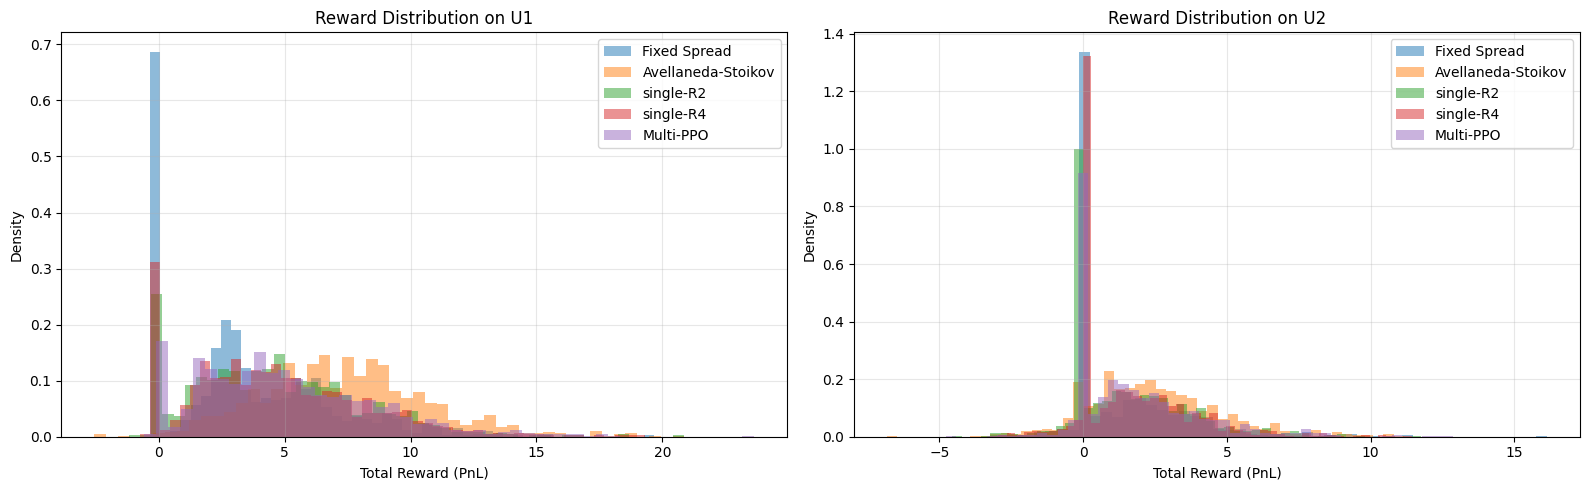

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, regime_name in enumerate(UNSEEN_REGIMES):
    ax = axes[idx]
    
    for method in methods:
        if method in results[regime_name]:
            pnls = results[regime_name][method]['all_pnls']
            ax.hist(pnls, bins=50, alpha=0.5, label=method, density=True)
    
    ax.set_title(f'Reward Distribution on {regime_name}', fontsize=12)
    ax.set_xlabel('Total Reward (PnL)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "exp1_reward_distributions.png"), dpi=150)
plt.show()

### Post-processing: Summarize into a DataFrame
Reshape the `results` dictionary into a long-form table (method × market) for saving and further analysis.

In [10]:
results_df.to_csv(str(OUTPUT_DIR / "exp1_results.csv"), index=False)
print("Results saved to ./outputs/exp1_results.csv")
print("\n" + "="*80)
print("Experiment 1 Complete!")
print("="*80)

Results saved to ./outputs/exp1_results.csv

Experiment 1 Complete!


### Output: Save Results to CSV
Save the aggregated evaluation table to the `outputs/` directory for later reuse and plotting.

## 9. Experiment 2: Reward Distribution Comparison Under Stress Market (U2)

In the stress market `U2`, run each method for `1000` episodes, plot the reward (PnL) probability density distribution, and compare robustness beyond single-point means from a left-tail risk perspective.

### Analysis: U2 Reward Distributions (PDF/KDE/CDF) and Dashed-Line Annotations
Plot each method's reward distribution in market `U2`, annotate values at the mean and the `q10` dashed line, and export KDE-only and CDF-only figures.

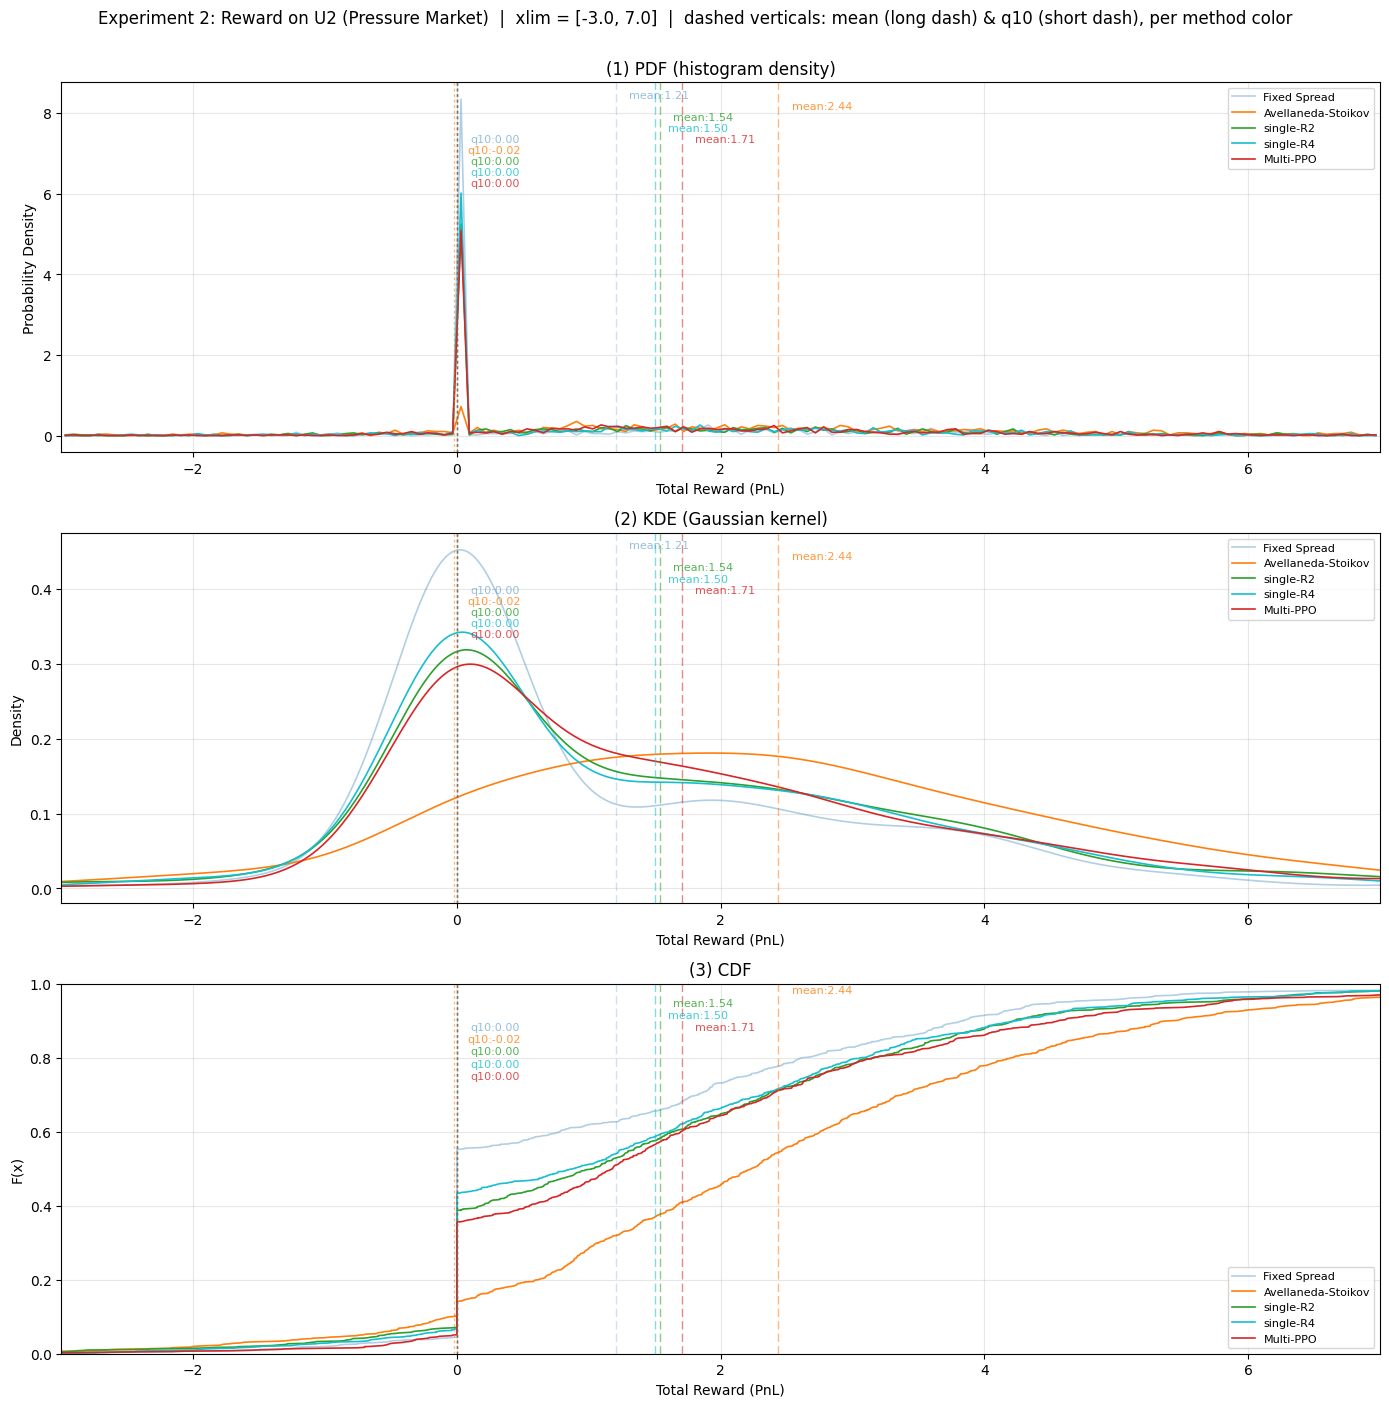

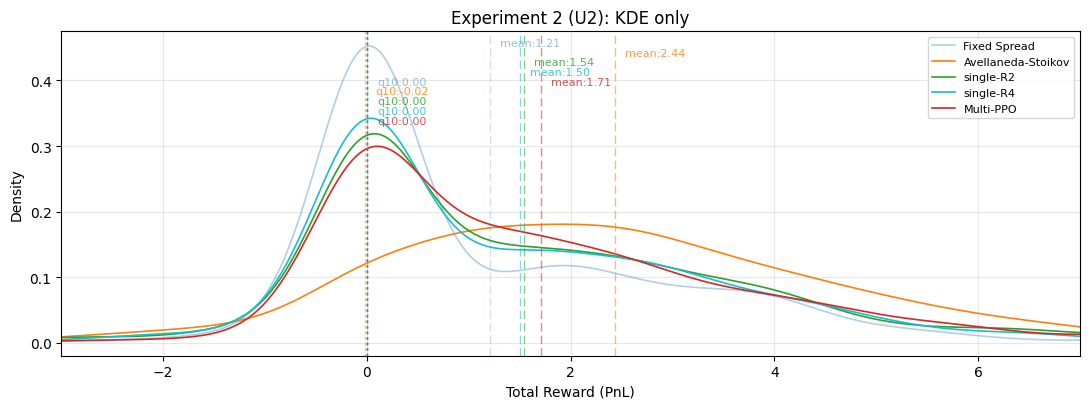

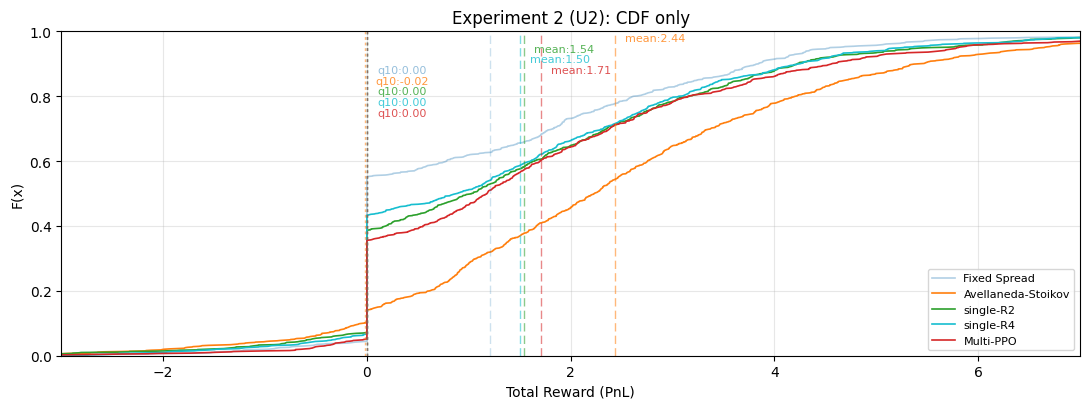


Experiment 2 (U2) Tail Risk Summary
            Method  U2 Mean PnL  U2 CVaR(10%)  U2 CVaR(30%)  U2 Mean(q_T)  U2 Quantile(10%)  U2 Quantile(1%)
Avellaneda-Stoikov     2.438174     -1.137202     -0.032091         0.075         -0.018361        -2.641611
      Fixed Spread     1.207548     -0.476788     -0.158929        -0.039          0.000000        -1.492334
         Multi-PPO     1.709268     -0.449662     -0.149887         0.106          0.000000        -1.412348
         single-R2     1.540687     -0.862459     -0.287486        -0.029          0.000000        -2.469836
         single-R4     1.503050     -0.675920     -0.225307        -0.013          0.000000        -1.966146


In [11]:
u2_name = 'U2'

methods = ['Fixed Spread', 'Avellaneda-Stoikov', 'single-R2', 'single-R4', 'Multi-PPO']
METHOD_COLORS = {
    'Fixed Spread': '#1f77b4',
    'Avellaneda-Stoikov': '#ff7f0e',
    'single-R2': '#2ca02c',
    'single-R4': '#17becf',
    'Multi-PPO': '#d62728',
}
XLO, XHI = -5.0, 5.0
XLO, XHI = -3.0, 7.0

from scipy.stats import gaussian_kde


def _line_alpha(method):
    return 0.35 if method == 'Fixed Spread' else 1.0


def _vline_alpha(method):
    return 0.22 if method == 'Fixed Spread' else 0.55


def _collect_series():
    out = {}
    for m in methods:
        if m in results[u2_name]:
            out[m] = np.asarray(results[u2_name][m]['all_pnls'], dtype=float).reshape(-1)
    return out


def _add_q10_mean_vlines(ax, series):
    """Mean: long-dashed line; q10: short-dashed line.
    Labels are shifted line-by-line following the method order to avoid overlap.
    """
    x_offset = 0.01 * (XHI - XLO)

    y_min, y_max = ax.get_ylim()
    y_span = max(1e-9, y_max - y_min)

    # Top starting y-position
    y_top = y_max - 0.02 * y_span

    # Vertical gap between rows
    row_gap = 0.03 * y_span

    # q10 is slightly lower than the mean
    pair_gap = 0.12 * y_span

    for i, m in enumerate(methods):
        if m not in series:
            continue

        pnls = series[m]
        c = METHOD_COLORS[m]
        va = _vline_alpha(m)

        mean_v = float(np.mean(pnls))
        q10_v = float(np.quantile(pnls, 0.10))

        # Draw dashed lines
        ax.axvline(mean_v, color=c, linestyle=(0, (6, 3)), linewidth=1.0, alpha=va)
        ax.axvline(q10_v, color=c, linestyle=(0, (2, 2)), linewidth=1.0, alpha=va)

        # One row per method
        y_mean_i = y_top - i * row_gap
        y_q10_i  = y_top - i * row_gap - pair_gap

        # mean label (horizontal)
        ax.text(
            mean_v + x_offset,
            y_mean_i,
            f"mean:{mean_v:.2f}",
            rotation=0,
            color=c,
            fontsize=8,
            alpha=min(1.0, va + 0.25),
            ha='left',
            va='top',
            clip_on=True,
        )

        # q10 label (horizontal)
        ax.text(
            q10_v + x_offset,
            y_q10_i,
            f"q10:{q10_v:.2f}",
            rotation=0,
            color=c,
            fontsize=8,
            alpha=min(1.0, va + 0.25),
            ha='left',
            va='top',
            clip_on=True,
        )


def _plot_pdf(ax, series):
    bins = np.linspace(XLO, XHI, 161)
    for m in methods:
        if m not in series:
            continue
        pnls = series[m]
        c = METHOD_COLORS[m]
        la = _line_alpha(m)
        hist, edges = np.histogram(pnls, bins=bins, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax.plot(centers, hist, linewidth=1.2, label=m, color=c, alpha=la)
    _add_q10_mean_vlines(ax, series)
    ax.set_xlim(XLO, XHI)
    ax.set_title('(1) PDF (histogram density)')
    ax.set_xlabel('Total Reward (PnL)')
    ax.set_ylabel('Probability Density')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)


def _plot_kde(ax, series):
    xgrid = np.linspace(XLO, XHI, 400)
    for m in methods:
        if m not in series:
            continue
        pnls = series[m]
        c = METHOD_COLORS[m]
        la = _line_alpha(m)
        if len(pnls) < 2:
            continue
        try:
            kde = gaussian_kde(pnls)
        except (np.linalg.LinAlgError, ValueError):
            continue
        ax.plot(xgrid, kde(xgrid), linewidth=1.2, label=m, color=c, alpha=la)
    _add_q10_mean_vlines(ax, series)
    ax.set_xlim(XLO, XHI)
    ax.set_title('(2) KDE (Gaussian kernel)')
    ax.set_xlabel('Total Reward (PnL)')
    ax.set_ylabel('Density')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)


def _plot_cdf(ax, series):
    for m in methods:
        if m not in series:
            continue
        pnls = series[m]
        c = METHOD_COLORS[m]
        la = _line_alpha(m)
        xs = np.sort(pnls)
        ys = np.arange(1, len(xs) + 1, dtype=float) / len(xs)
        ax.plot(xs, ys, linewidth=1.2, label=m, color=c, alpha=la)
    _add_q10_mean_vlines(ax, series)
    ax.set_xlim(XLO, XHI)
    ax.set_ylim(0, 1)
    ax.set_title('(3) CDF')
    ax.set_xlabel('Total Reward (PnL)')
    ax.set_ylabel('F(x)')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)


series = _collect_series()

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle(
    ('Experiment 2: Reward on U2 (Pressure Market)  |  xlim = [{}, {}]  |  '
     'dashed verticals: mean (long dash) & q10 (short dash), per method color').format(XLO, XHI),
    fontsize=12,
    y=1.002,
)
_plot_pdf(axes[0], series)
_plot_kde(axes[1], series)
_plot_cdf(axes[2], series)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'exp2_u2_reward_density.png'), dpi=150*3, bbox_inches='tight')
plt.show()

# KDE-only figure (extracted from the 3-panel plot)
fig_kde, ax_kde = plt.subplots(1, 1, figsize=(11, 4.2))
_plot_kde(ax_kde, series)
ax_kde.set_title('Experiment 2 (U2): KDE only')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'exp2_u2_kde_only.png'), dpi=150*3, bbox_inches='tight')
plt.show()

# CDF-only figure (extracted from the 3-panel plot)
fig_cdf, ax_cdf = plt.subplots(1, 1, figsize=(11, 4.2))
_plot_cdf(ax_cdf, series)
ax_cdf.set_title('Experiment 2 (U2): CDF only')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'exp2_u2_cdf_only.png'), dpi=150*3, bbox_inches='tight')
plt.show()

# Output left-tail risk summary (1%/10% quantiles + CVaR(10%)/mean)
rows = []
for m in methods:
    if m not in results[u2_name]:
        continue
    r = results[u2_name][m]
    pnls = np.asarray(r['all_pnls'])
    q01 = float(np.quantile(pnls, 0.01))
    q10 = float(np.quantile(pnls, 0.10))
    rows.append({
        'Method': m,
        'U2 Mean PnL': float(r['mean_pnl']),
        'U2 CVaR(10%)': float(r['cvar_10']),
        'U2 CVaR(30%)': float(r['cvar_30']),
        'U2 Mean(q_T)': float(r['mean_qt']),
        'U2 Quantile(10%)': q10,
        'U2 Quantile(1%)': q01,
    })

df_tail = pd.DataFrame(rows)
print('\n' + '=' * 80)
print('Experiment 2 (U2) Tail Risk Summary')
print('=' * 80)
print(df_tail.sort_values('Method').to_string(index=False))


### Visualization: Stepwise Quote Depth & Midprice (Bid/Ask Depth & Midprice)
Aggregate the mean and quantile bands of bid/ask depth and midprice at each step across episodes on U1/U2 to compare quoting behavior across methods.

### Visualization: Stepwise Inventory Trajectories (Inventory)
On U1/U2, aggregate the mean and quantile intervals of inventory at each step across episodes, and mark the tail quantiles at the final time.

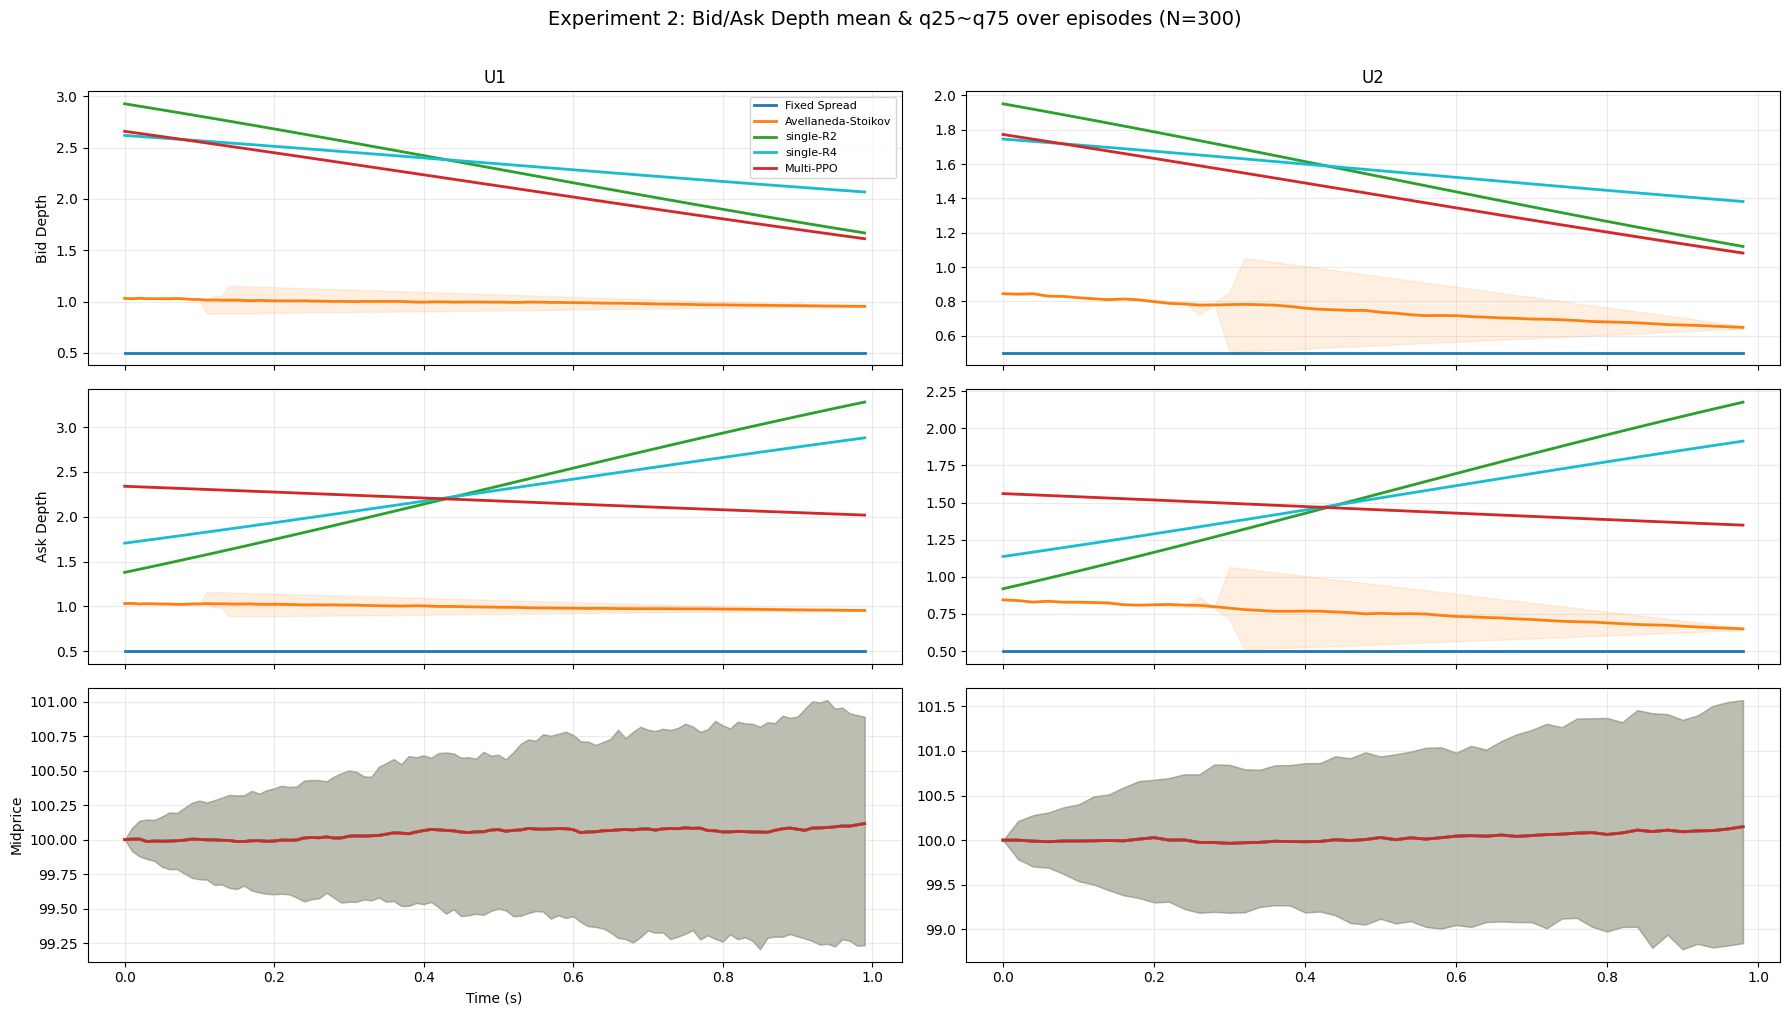

In [12]:
# Episode-wise (per step) statistics: mean bid/ask/midprice and q25~q75
# Note: q25/q75 are computed along the episode dimension, so each step has a mean curve and an interval band.

import numpy as np
import matplotlib.pyplot as plt

from mbt_gym.gym.index_names import ASSET_PRICE_INDEX, INVENTORY_INDEX, TIME_INDEX
from mbt_gym.agents.SbAgent import SbAgent
from mbt_gym.agents.BaselineAgents import FixedSpreadAgent

# Number of episodes for plotting statistics (too large may be slow; adjust if needed)
N_QUOTE_EPISODES = int(min(globals().get('N_EVAL_EPISODES', 1000), 300))
EVAL_SEED = int(globals().get('EVAL_SEED', 123))

# Methods list (include PPO methods only if the corresponding models exist)
quote_methods = ['Fixed Spread', 'Avellaneda-Stoikov']
if 'single_ppo_model' in globals() and single_ppo_model is not None:
    quote_methods.append('single-R2')
if 'single_r4_ppo_model' in globals() and single_r4_ppo_model is not None:
    quote_methods.append('single-R4')
if 'multi_ppo_model' in globals() and multi_ppo_model is not None:
    quote_methods.append('Multi-PPO')

regimes = list(globals().get('UNSEEN_REGIMES', ['U1', 'U2']))


from mbt_gym.agents.BaselineAgents import AvellanedaStoikovAgent


class _PPOPhysicalAgent:
    """SB3 PPO: map normalized model outputs back to physical actions (depth / half-spread)."""

    def __init__(self, model, env, reduced_training_indices, num_actions: int):
        self.model = model
        self.env = env
        self.reduced_training_indices = reduced_training_indices
        self.num_actions = num_actions

    def get_action(self, obs: np.ndarray) -> np.ndarray:
        state = obs[:, self.reduced_training_indices]
        action_norm = self.model.predict(state, deterministic=True)[0]
        action_norm = np.asarray(action_norm).reshape(state.shape[0], self.num_actions)
        return self.env.normalise_action(action_norm, inverse=True)


class _ASPhysicalAgent:
    """AS: denormalize observations and output physical actions (depth / half-spread)."""

    def __init__(self, env, risk_aversion: float):
        self.env = env
        self.base_agent = AvellanedaStoikovAgent(risk_aversion=risk_aversion, env=env)

    def get_action(self, obs: np.ndarray) -> np.ndarray:
        raw_obs = self.env.normalise_observation(obs, inverse=True)
        return self.base_agent.get_action(raw_obs)


def _make_agent(method: str, env):
    if method == 'Fixed Spread':
        return FixedSpreadAgent(env, half_spread=0.5)
    if method == 'Avellaneda-Stoikov':
        return _ASPhysicalAgent(env, risk_aversion=globals().get('AS_RISK_AVERSION', 0.1))
    if method == 'single-R2':
        return _PPOPhysicalAgent(
            single_ppo_model,
            env,
            reduced_training_indices=[INVENTORY_INDEX, TIME_INDEX],
            num_actions=single_ppo_model.action_space.shape[0],
        )
    if method == 'single-R4':
        return _PPOPhysicalAgent(
            single_r4_ppo_model,
            env,
            reduced_training_indices=[INVENTORY_INDEX, TIME_INDEX],
            num_actions=single_r4_ppo_model.action_space.shape[0],
        )
    if method == 'Multi-PPO':
        return _PPOPhysicalAgent(
            multi_ppo_model,
            env,
            reduced_training_indices=[INVENTORY_INDEX, TIME_INDEX],
            num_actions=multi_ppo_model.action_space.shape[0],
        )
    raise ValueError(f'Unknown method: {method}')


def _evaluate_quotes_over_episodes(method: str, regime_name: str):
    # Each episode uses the environment's own RNG for natural evolution (no forced common random numbers).
    base_seed = EVAL_SEED
    env = create_market_env(regime_name, num_trajectories=1, seed=base_seed)
    agent = _make_agent(method, env)

    T = int(env.n_steps)
    bid_depths = np.zeros((N_QUOTE_EPISODES, T), dtype=float)
    ask_depths = np.zeros((N_QUOTE_EPISODES, T), dtype=float)
    mid = np.zeros((N_QUOTE_EPISODES, T), dtype=float)

    time_grid = np.arange(T, dtype=float) * float(env.step_size)

    for ep in range(N_QUOTE_EPISODES):
        obs = env.reset()
        done = False
        t = 0

        while not done:
            # Consistent convention: agent outputs physical actions (depth / half-spread)
            action_phys = agent.get_action(obs)

            # env.step() expects normalized actions
            action_norm = env.normalise_action(action_phys, inverse=False)

            bid_depth = float(action_phys[0, 0])
            ask_depth = float(action_phys[0, 1])

            mid_price = float(env.state[0, ASSET_PRICE_INDEX])
            bid_depths[ep, t] = bid_depth
            ask_depths[ep, t] = ask_depth
            mid[ep, t] = mid_price

            obs, _, done, _ = env.step(action_norm)
            t += 1

        if t != T:
            raise RuntimeError(f'Unexpected episode length: got {t}, expected {T}')

    stats = {
        'time_grid': time_grid,
        'bid_depth_mean': bid_depths.mean(axis=0),
        'bid_depth_q25': np.quantile(bid_depths, 0.25, axis=0),
        'bid_depth_q75': np.quantile(bid_depths, 0.75, axis=0),
        'ask_depth_mean': ask_depths.mean(axis=0),
        'ask_depth_q25': np.quantile(ask_depths, 0.25, axis=0),
        'ask_depth_q75': np.quantile(ask_depths, 0.75, axis=0),
        'mid_mean': mid.mean(axis=0),
        'mid_q25': np.quantile(mid, 0.25, axis=0),
        'mid_q75': np.quantile(mid, 0.75, axis=0),
    }
    return stats


# Plot layout: 3 rows (bid/ask/midprice) and 2 columns (U1/U2)
fig, axes = plt.subplots(3, len(regimes), figsize=(18, 10), sharex='col')

if len(regimes) == 1:
    axes = np.array(axes).reshape(3, 1)

for col, reg in enumerate(regimes):
    for method in quote_methods:
        if reg not in globals().get('results', {}) or method not in globals().get('results', {}).get(reg, {}):
            # If PnL results exist, the method was likely evaluated; otherwise skip to avoid missing data
            pass

        c = METHOD_COLORS.get(method, None) if 'METHOD_COLORS' in globals() else None
        stats = _evaluate_quotes_over_episodes(method, reg)

        t = stats['time_grid']

        # bid depth
        axes[0, col].plot(t, stats['bid_depth_mean'], color=c, linewidth=2.0, label=method)
        axes[0, col].fill_between(t, stats['bid_depth_q25'], stats['bid_depth_q75'], color=c, alpha=0.12)

        # ask depth
        axes[1, col].plot(t, stats['ask_depth_mean'], color=c, linewidth=2.0, label=method)
        axes[1, col].fill_between(t, stats['ask_depth_q25'], stats['ask_depth_q75'], color=c, alpha=0.12)

        # Midprice (mid)
        axes[2, col].plot(t, stats['mid_mean'], color=c, linewidth=2.0, label=method)
        axes[2, col].fill_between(t, stats['mid_q25'], stats['mid_q75'], color=c, alpha=0.12)

    axes[0, col].set_title(f'{reg}')
    axes[0, col].grid(True, alpha=0.25)
    axes[1, col].grid(True, alpha=0.25)
    axes[2, col].grid(True, alpha=0.25)

axes[0, 0].set_ylabel('Bid Depth')
axes[1, 0].set_ylabel('Ask Depth')
axes[2, 0].set_ylabel('Midprice')
axes[2, 0].set_xlabel('Time (s)')

# Place legend only in the top-left corner to avoid duplicates
handles, labels = axes[0, 0].get_legend_handles_labels()
if len(handles) > 0:
    axes[0, 0].legend(handles, labels, loc='best', fontsize=8)

fig.suptitle(f'Experiment 2: Bid/Ask Depth mean & q25~q75 over episodes (N={N_QUOTE_EPISODES})', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


### Debug: Normalization and Index Consistency Check
Quickly verify whether observations/actions in the evaluation environment are within the expected normalization ranges, and whether PPO input indices match.

[Final tail] U1 | Fixed Spread | q01=-9.000, q99=7.000
[Final tail] U1 | Avellaneda-Stoikov | q01=-5.010, q99=4.010
[Final tail] U1 | single-R2 | q01=-3.010, q99=2.010
[Final tail] U1 | single-R4 | q01=-3.000, q99=3.000
[Final tail] U1 | Multi-PPO | q01=-3.010, q99=3.000
[Final tail] U2 | Fixed Spread | q01=-5.000, q99=5.000
[Final tail] U2 | Avellaneda-Stoikov | q01=-3.000, q99=3.000
[Final tail] U2 | single-R2 | q01=-2.000, q99=2.000
[Final tail] U2 | single-R4 | q01=-2.010, q99=2.000
[Final tail] U2 | Multi-PPO | q01=-3.000, q99=3.000


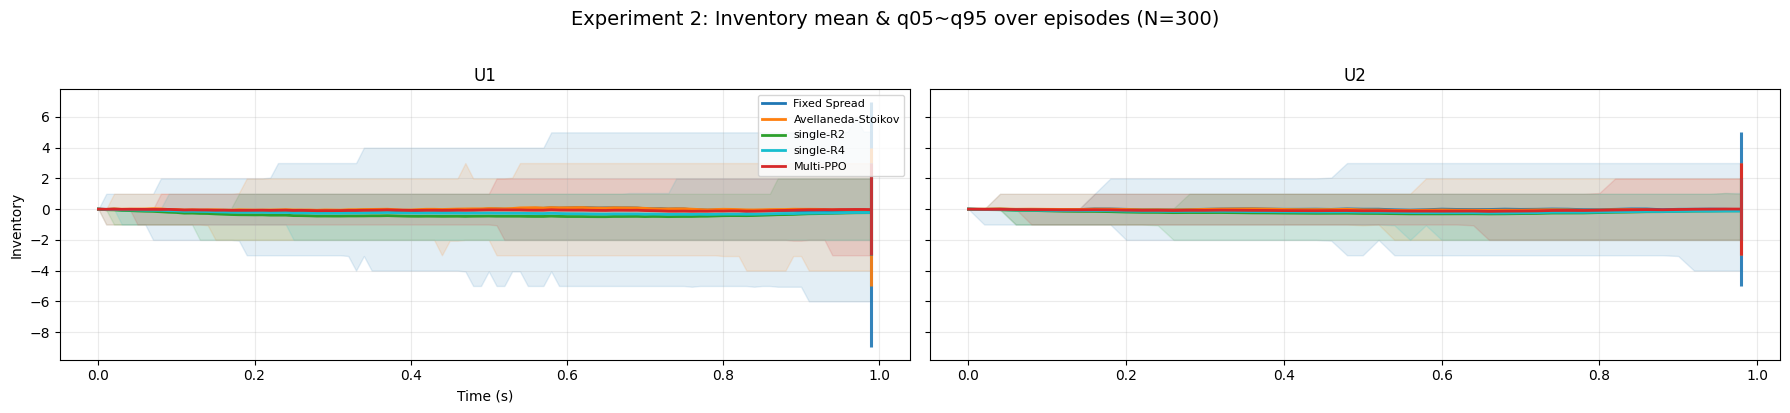

In [13]:
# Inventory (per step) variation: mean + q05~q95 over episodes

import numpy as np
import matplotlib.pyplot as plt

from mbt_gym.gym.index_names import INVENTORY_INDEX

# Reuse the same sampling size/seed as the previous plotting cell
N_INV_EPISODES = int(globals().get('N_QUOTE_EPISODES', 100))
EVAL_SEED = int(globals().get('EVAL_SEED', 123))

# Methods list: reuse quote_methods first (it already includes models that exist among Fixed/AS/Single/Multi)
inventory_methods = list(globals().get('quote_methods', ['Fixed Spread', 'Avellaneda-Stoikov']))

regimes = list(globals().get('UNSEEN_REGIMES', ['U1', 'U2']))


def _evaluate_inventory_over_episodes(method: str, regime_name: str):
    base_seed = EVAL_SEED
    env = create_market_env(regime_name, num_trajectories=1, seed=base_seed)
    agent = _make_agent(method, env)  # Reuse the agent factory from the previous cell

    T = int(env.n_steps)
    inv = np.zeros((N_INV_EPISODES, T), dtype=float)

    time_grid = np.arange(T, dtype=float) * float(env.step_size)

    for ep in range(N_INV_EPISODES):
        obs = env.reset()
        done = False
        t = 0

        while not done:
            inv[ep, t] = float(env.state[0, INVENTORY_INDEX])

            # Consistent convention: agent outputs physical actions (depth / half-spread)
            action_phys = agent.get_action(obs)
            action_norm = env.normalise_action(action_phys, inverse=False)

            obs, _, done, _ = env.step(action_norm)
            t += 1

        if t != T:
            raise RuntimeError(f'Unexpected episode length: got {t}, expected {T}')

    inv_q05 = np.quantile(inv, 0.05, axis=0)
    inv_q95 = np.quantile(inv, 0.95, axis=0)

    # Final time point: verify the tail is not clipped to [-1, 1]
    inv_final = inv[:, -1]
    inv_q01_final = float(np.quantile(inv_final, 0.01))
    inv_q99_final = float(np.quantile(inv_final, 0.99))

    return {
        'time_grid': time_grid,
        'inv_mean': inv.mean(axis=0),
        'inv_q05': inv_q05,
        'inv_q95': inv_q95,
        'inv_q01_final': inv_q01_final,
        'inv_q99_final': inv_q99_final,
    }


fig, axes = plt.subplots(1, len(regimes), figsize=(18, 4), sharey=True)
if len(regimes) == 1:
    axes = [axes]

for col, reg in enumerate(regimes):
    for method in inventory_methods:
        c = METHOD_COLORS.get(method, None) if 'METHOD_COLORS' in globals() else None
        stats = _evaluate_inventory_over_episodes(method, reg)

        t = stats['time_grid']
        axes[col].plot(t, stats['inv_mean'], color=c, linewidth=2.0, label=method)
        axes[col].fill_between(t, stats['inv_q05'], stats['inv_q95'], color=c, alpha=0.12)

        # Final-time q01/q99: mark the tail with small vertical bars
        t_end = float(t[-1])
        axes[col].vlines(
            t_end,
            stats['inv_q01_final'],
            stats['inv_q99_final'],
            color=c,
            linewidth=2.2,
            alpha=0.9,
            zorder=3,
        )
        print(f"[Final tail] {reg} | {method} | q01={stats['inv_q01_final']:.3f}, q99={stats['inv_q99_final']:.3f}")

    axes[col].set_title(reg)
    axes[col].grid(True, alpha=0.25)

axes[0].set_ylabel('Inventory')
axes[0].set_xlabel('Time (s)')

# Place legend only on the first subplot to avoid duplicates
handles, labels = axes[0].get_legend_handles_labels()
if len(handles) > 0:
    axes[0].legend(handles, labels, loc='best', fontsize=8)

fig.suptitle(f'Experiment 2: Inventory mean & q05~q95 over episodes (N={N_INV_EPISODES})', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()
